In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

All good!


In [3]:
df = pd.read_csv('startup_funding.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (3044, 10)

Columns: ['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks']

First 5 rows:


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [4]:
print(df.isnull().sum())

Sr No                   0
Date dd/mm/yyyy         0
Startup Name            0
Industry Vertical     171
SubVertical           936
City  Location        180
Investors Name         24
InvestmentnType         4
Amount in USD         960
Remarks              2625
dtype: int64


In [5]:
# imp columns
df = df[['Startup Name', 'Industry Vertical', 'City  Location', 'Investors Name', 'Amount in USD']]
df = df.dropna(subset=['Amount in USD'])
df = df.reset_index(drop=True)

print("Rows remaining:", len(df))
print("\nMissing values now:")
print(df.isnull().sum())

Rows remaining: 2084

Missing values now:
Startup Name           0
Industry Vertical    131
City  Location       135
Investors Name        20
Amount in USD          0
dtype: int64


In [6]:
print(df['Amount in USD'].dtype)
print("\nSample values:")
print(df['Amount in USD'].head(10))

str

Sample values:
0    20,00,00,000
1       80,48,394
2     1,83,58,860
3       30,00,000
4       18,00,000
5       90,00,000
6    15,00,00,000
7       60,00,000
8     7,00,00,000
9     5,00,00,000
Name: Amount in USD, dtype: str


In [7]:
df['Amount in USD'] = df['Amount in USD'].str.replace(',', '')
df['Amount in USD'] = pd.to_numeric(df['Amount in USD'], errors='coerce')
df = df.dropna(subset=['Amount in USD'])
df = df.reset_index(drop=True)

print("Rows remaining:", len(df))
print("\nData type now:", df['Amount in USD'].dtype)
print("\nSample values:")
print(df['Amount in USD'].head(10))

Rows remaining: 2065

Data type now: float64

Sample values:
0    200000000.0
1      8048394.0
2     18358860.0
3      3000000.0
4      1800000.0
5      9000000.0
6    150000000.0
7      6000000.0
8     70000000.0
9     50000000.0
Name: Amount in USD, dtype: float64


In [8]:
top_sectors = df['Industry Vertical'].value_counts().head(10)
print(top_sectors)


Industry Vertical
Consumer Internet    589
Technology           310
eCommerce            126
Finance               57
Healthcare            44
ECommerce             37
E-Commerce            26
Logistics             23
Education             19
Food & Beverage       15
Name: count, dtype: int64


In [9]:
df['Industry Vertical'] = df['Industry Vertical'].str.strip()
df['Industry Vertical'] = df['Industry Vertical'].replace({
    'ECommerce': 'eCommerce',
    'E-Commerce': 'eCommerce',
    'ecommerce': 'eCommerce'
})

top_sectors = df['Industry Vertical'].value_counts().head(10)
print(top_sectors)

Industry Vertical
Consumer Internet    589
Technology           310
eCommerce            191
Finance               57
Healthcare            44
Logistics             23
Education             19
Food & Beverage       15
Ed-Tech               12
FinTech                9
Name: count, dtype: int64


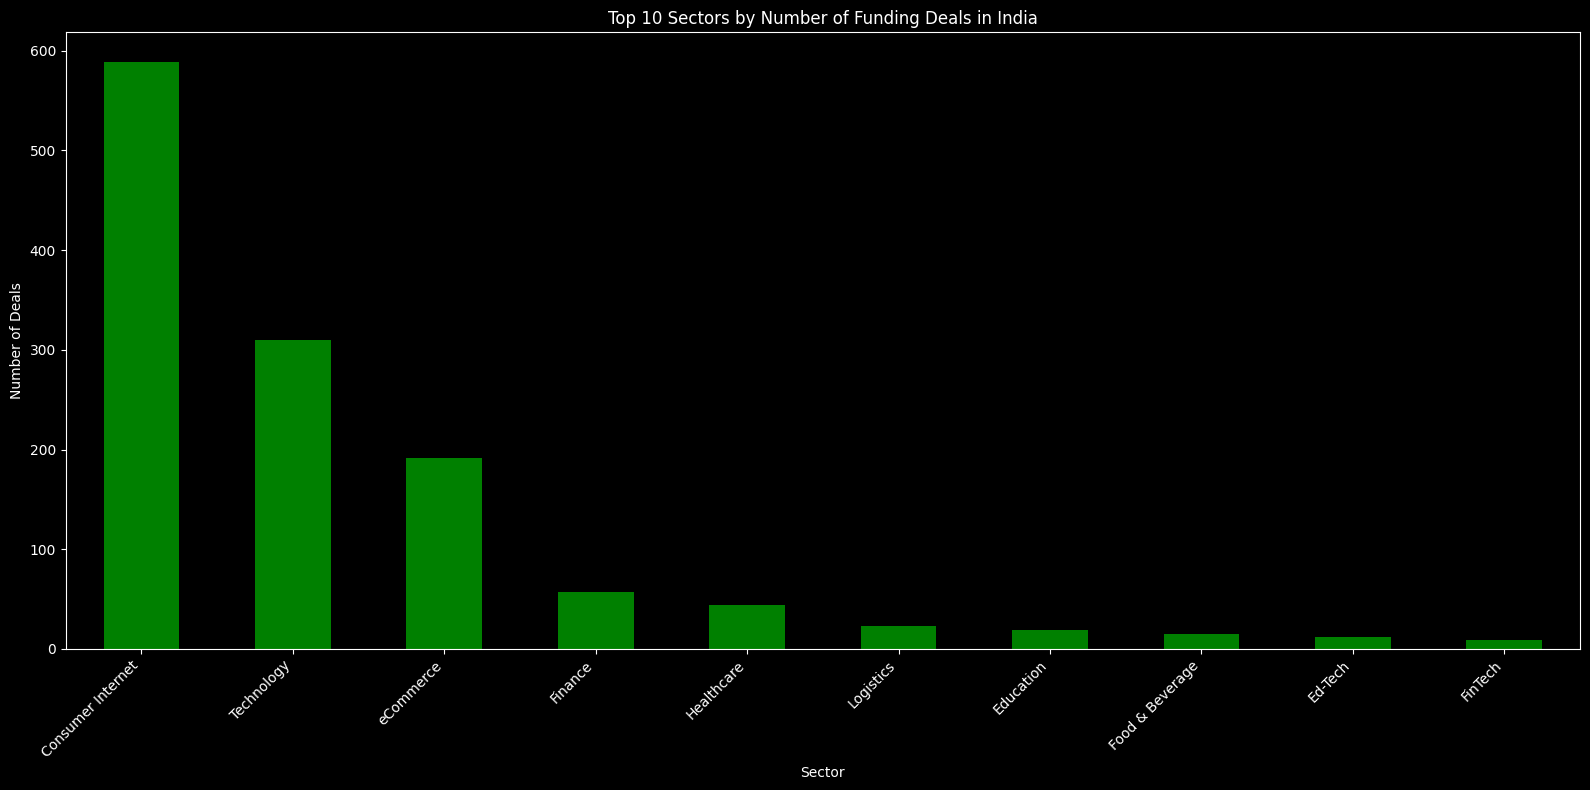

In [16]:
plt.figure(figsize=(16, 8))
top_sectors.plot(kind='bar', color='green')

plt.title('Top 10 Sectors by Number of Funding Deals in India')
plt.xlabel('Sector')
plt.ylabel('Number of Deals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('top_sectors.png')
plt.show()

In [17]:
top_cities = df['City  Location'].value_counts().head(10)
print(top_cities)

City  Location
Bangalore    456
Mumbai       401
New Delhi    241
Gurgaon      198
Bengaluru    126
Chennai       75
Hyderabad     72
Pune          71
Noida         55
Gurugram      43
Name: count, dtype: int64


In [18]:
df['City  Location'] = df['City  Location'].str.strip()
df['City  Location'] = df['City  Location'].replace({
    'Bengaluru': 'Bangalore',
    'Gurugram': 'Gurgaon',
    'New Delhi': 'Delhi',
    'Noida': 'Delhi'
})

top_cities = df['City  Location'].value_counts().head(10)
print(top_cities)

City  Location
Bangalore    582
Mumbai       401
Delhi        321
Gurgaon      241
Chennai       75
Hyderabad     72
Pune          71
Ahmedabad     27
Jaipur        14
Kolkata       10
Name: count, dtype: int64


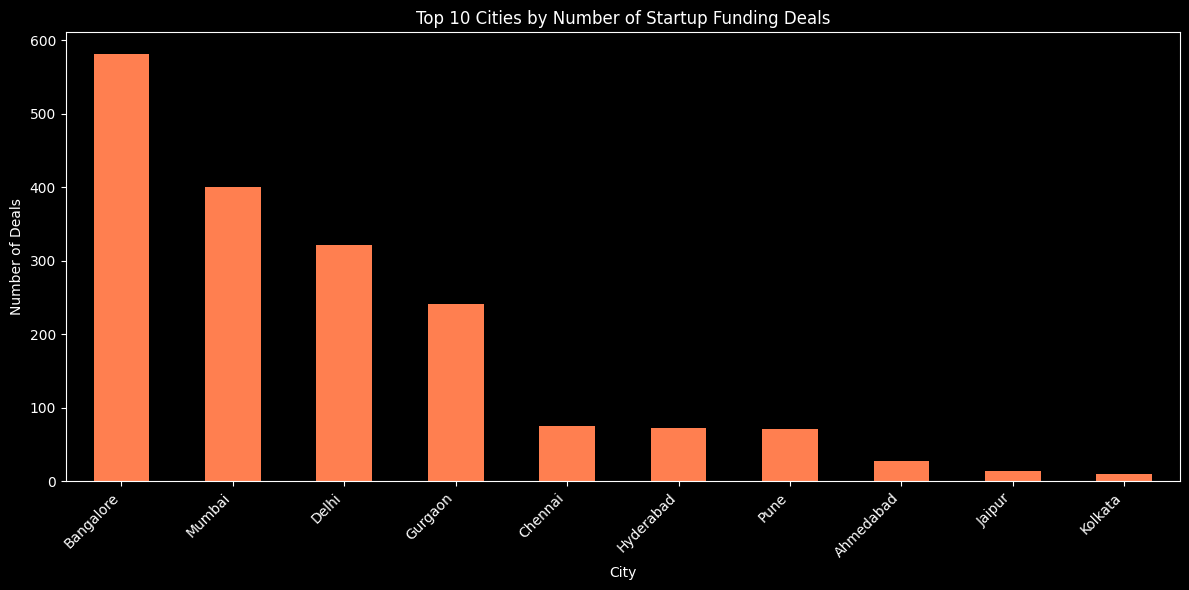

In [19]:
plt.figure(figsize=(12, 6))
top_cities.plot(kind='bar', color='coral')

plt.title('Top 10 Cities by Number of Startup Funding Deals')
plt.xlabel('City')
plt.ylabel('Number of Deals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('top_cities.png')
plt.show()

In [20]:
sector_funding = df.groupby('Industry Vertical')['Amount in USD'].sum()
sector_funding = sector_funding.sort_values(ascending=False).head(10)
print(sector_funding)

Industry Vertical
eCommerce                           7.891521e+09
Consumer Internet                   6.253084e+09
Transportation                      3.916632e+09
Technology                          2.229708e+09
Finance                             1.971438e+09
FinTech                             1.220711e+09
Online Marketplace                  7.001430e+08
E-Commerce & M-Commerce platform    6.800000e+08
B2B                                 5.870000e+08
Ecommerce Marketplace               5.000000e+08
Name: Amount in USD, dtype: float64


In [21]:
# Convert to billions and round to 2 decimal places
sector_funding_billions = (sector_funding / 1_000_000_000).round(2)
print(sector_funding_billions)

Industry Vertical
eCommerce                           7.89
Consumer Internet                   6.25
Transportation                      3.92
Technology                          2.23
Finance                             1.97
FinTech                             1.22
Online Marketplace                  0.70
E-Commerce & M-Commerce platform    0.68
B2B                                 0.59
Ecommerce Marketplace               0.50
Name: Amount in USD, dtype: float64


In [22]:
df['Industry Vertical'] = df['Industry Vertical'].replace({
    'FinTech': 'Finance',
    'Fintech': 'Finance'
})

sector_funding = df.groupby('Industry Vertical')['Amount in USD'].sum()
sector_funding_billions = (sector_funding / 1_000_000_000).round(2)
sector_funding_billions = sector_funding_billions.sort_values(ascending=False).head(10)
print(sector_funding_billions)

Industry Vertical
eCommerce                             7.89
Consumer Internet                     6.25
Transportation                        3.92
Finance                               3.20
Technology                            2.23
Online Marketplace                    0.70
E-Commerce & M-Commerce platform      0.68
B2B                                   0.59
Ecommerce Marketplace                 0.50
Car Aggregator & Retail Mobile App    0.50
Name: Amount in USD, dtype: float64


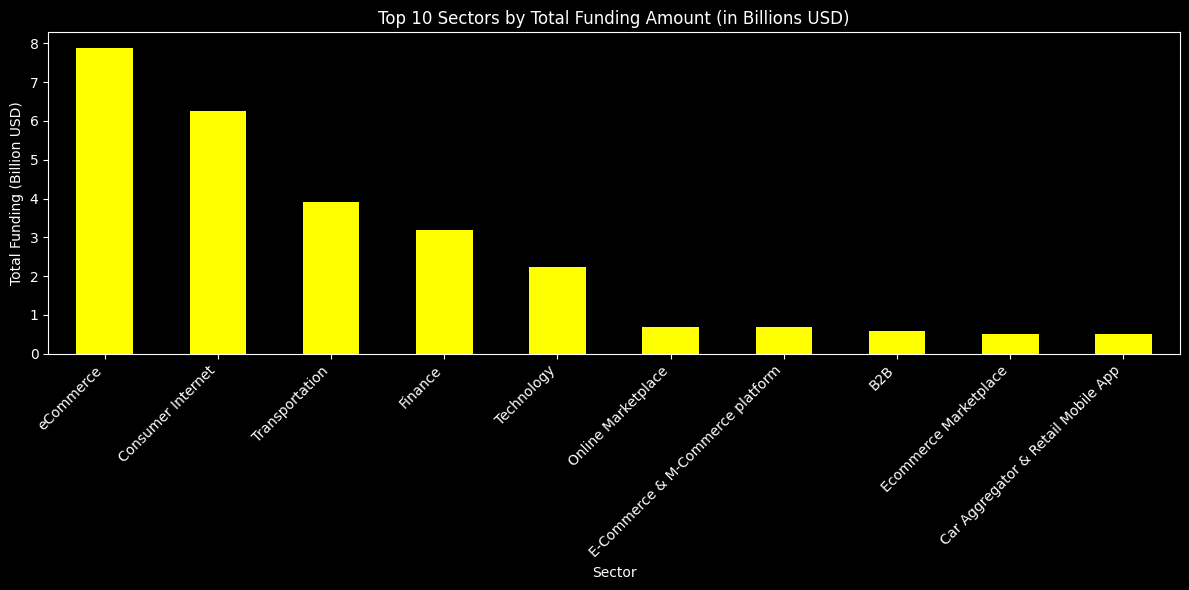

In [23]:
plt.figure(figsize=(12, 6))
sector_funding_billions.plot(kind='bar', color='yellow')

plt.title('Top 10 Sectors by Total Funding Amount (in Billions USD)')
plt.xlabel('Sector')
plt.ylabel('Total Funding (Billion USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('sector_funding_amount.png')
plt.show()

In [24]:
amounts = df['Amount in USD'].values

avg_deal = np.mean(amounts)
median_deal = np.median(amounts)
largest_deal = np.max(amounts)
smallest_deal = np.min(amounts)

print(f"Average deal size:  ${avg_deal/1_000_000:.2f} Million")
print(f"Median deal size:   ${median_deal/1_000_000:.2f} Million")
print(f"Largest deal:       ${largest_deal/1_000_000:.2f} Million")
print(f"Smallest deal:      ${smallest_deal/1_000_000:.2f} Million")

Average deal size:  $18.43 Million
Median deal size:   $1.70 Million
Largest deal:       $3900.00 Million
Smallest deal:      $0.02 Million


In [26]:
top_sector_by_deals = df['Industry Vertical'].value_counts().idxmax()
top_sector_by_deals_count = df['Industry Vertical'].value_counts().max()

top_sector_by_money = sector_funding_billions.idxmax()
top_sector_by_money_amount = sector_funding_billions.max()

top_city = df['City  Location'].value_counts().idxmax()
top_city_count = df['City  Location'].value_counts().max()

print("=" * 50)
print("KEY FINDINGS — INDIAN STARTUP FUNDING ANALYSIS")
print("=" * 50)
print(f"Total deals analyzed: {len(df)}")
print(f"Top sector by deals: {top_sector_by_deals} ({top_sector_by_deals_count} deals)")
print(f"Top sector by money: {top_sector_by_money} (${top_sector_by_money_amount:.2f} Billion)")
print(f"Top city: {top_city} ({top_city_count} deals)")
print(f"Typical deal size: ${median_deal/1_000_000:.2f} Million (median)")
print(f"Largest single deal: ${largest_deal/1_000_000:.2f} Million")
print("=" * 50)

KEY FINDINGS — INDIAN STARTUP FUNDING ANALYSIS
Total deals analyzed: 2065
Top sector by deals: Consumer Internet (589 deals)
Top sector by money: eCommerce ($7.89 Billion)
Top city: Bangalore (582 deals)
Typical deal size: $1.70 Million (median)
Largest single deal: $3900.00 Million
